### Sentence Similarity

In [6]:
import numpy as np
import nltk
nltk.download('punkt')
nltk.download("punkt_tab")


[nltk_data] Downloading package punkt to /Users/sv/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/sv/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [7]:
from nltk.tokenize import word_tokenize
def tokenize_text(text):
    return word_tokenize(text.lower())

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# List of sentences for comparison
sentences = [
    "The cat sat on the mat.",
    "A dog is playing in the yard.",
    "I need to buy groceries today.",
    "The feline was resting on the rug.",
    "Canines enjoy outdoor activities.",
    "My shopping list includes milk and bread.",
    "The weather is beautiful today.",
    "Programming requires logical thinking."
]

# Query sentence
query = "My pet cat is sleeping on the carpet."

def sentence_embedding(sentence, embeddings, word2idx):
    tokens = tokenize_text(sentence)
    vecs = [
        embeddings[word2idx[w]]
        for w in tokens
        if w in word2idx
    ]
    return np.mean(vecs, axis=0)

#### PyTorch embeddings

In [8]:
import pickle
with open("word2vec_embeddings.pkl", "rb") as f:
    data = pickle.load(f)

embeddings = data["embeddings"]
word2idx = data["word2idx"]

query_vec = sentence_embedding(query, embeddings, word2idx)

print("PyTorch Skip-Gram (100d)")
for s in sentences:
    s_vec = sentence_embedding(s, embeddings, word2idx)
    sim = cosine_sim(query_vec, s_vec)
    print(f"{sim:.4f}  |  {s}")

PyTorch Skip-Gram (100d)
0.6865  |  The cat sat on the mat.
0.4117  |  A dog is playing in the yard.
0.3320  |  I need to buy groceries today.
0.1725  |  The feline was resting on the rug.
0.3368  |  Canines enjoy outdoor activities.
0.4959  |  My shopping list includes milk and bread.
0.3121  |  The weather is beautiful today.
0.4451  |  Programming requires logical thinking.


#### Gensim Word2Vec trained on Text8 100d

In [13]:
with open("word2vec_gensim_embeddings.pkl", "rb") as t:
    data_gensim = pickle.load(t)
embeddings_gensim = data_gensim["embeddings"]
word2idx_gensim = data_gensim["word2idx"]

query_vec_gensim = sentence_embedding(query, embeddings_gensim, word2idx_gensim)

print("\nGensim Word2Vec (300d)")
for s in sentences:
    s_vec_gensim = sentence_embedding(s, embeddings_gensim, word2idx_gensim)
    sim_gensim = cosine_sim(query_vec_gensim, s_vec_gensim)
    print(f"{sim_gensim:.4f}  |  {s}")


Gensim Word2Vec (300d)
0.6822  |  The cat sat on the mat.
0.6015  |  A dog is playing in the yard.
0.2014  |  I need to buy groceries today.
0.4951  |  The feline was resting on the rug.
0.0770  |  Canines enjoy outdoor activities.
0.4537  |  My shopping list includes milk and bread.
0.4958  |  The weather is beautiful today.
0.0561  |  Programming requires logical thinking.


#### Gensim Word2Vec Google News (300d)

In [14]:
with open("word2vec_google_news_300_embeddings.pkl", "rb") as g:
    data_google = pickle.load(g)
embeddings_google = data_google["embeddings"]
word2idx_google = data_google["word2idx"]

query_vec_google = sentence_embedding(query, embeddings_google, word2idx_google)
print("\nGensim Word2Vec Google News (300d)")
for s in sentences:
    s_vec_google = sentence_embedding(s, embeddings_google, word2idx_google)
    sim_google = cosine_sim(query_vec_google, s_vec_google)
    print(f"{sim_google:.4f}  |  {s}")


Gensim Word2Vec Google News (300d)
0.7369  |  The cat sat on the mat.
0.6483  |  A dog is playing in the yard.
0.3718  |  I need to buy groceries today.
0.7794  |  The feline was resting on the rug.
0.4281  |  Canines enjoy outdoor activities.
0.4970  |  My shopping list includes milk and bread.
0.4310  |  The weather is beautiful today.
0.2979  |  Programming requires logical thinking.


#### Gensim FastText Wiki News Subwords (300d)

In [15]:
with open("fasttext-wiki-news-subwords-300_embeddings.pkl", "rb") as h:
    data_fasttext = pickle.load(h)
embeddings_fasttext = data_fasttext["embeddings"]
word2idx_fasttext = data_fasttext["word2idx"]

query_vec_fasttext = sentence_embedding(query, embeddings_fasttext, word2idx_fasttext)
print("\nFastText Wiki News Subwords (300d)")
for s in sentences:
    s_vec_fasttext = sentence_embedding(s, embeddings_fasttext, word2idx_fasttext)
    sim_fasttext = cosine_sim(query_vec_fasttext, s_vec_fasttext)
    print(f"{sim_fasttext:.4f}  |  {s}")


FastText Wiki News Subwords (300d)
0.9114  |  The cat sat on the mat.
0.8512  |  A dog is playing in the yard.
0.5858  |  I need to buy groceries today.
0.9247  |  The feline was resting on the rug.
0.6504  |  Canines enjoy outdoor activities.
0.8350  |  My shopping list includes milk and bread.
0.8090  |  The weather is beautiful today.
0.6135  |  Programming requires logical thinking.


Across all models performance, the pretrained embeddings (Google News Word2Vec and FastText) typically produce more semantically rankings because they were trained on much larger corpora(300 dim vectors) as they both have a higher cosine similarity score for severy sentences than the other two model. While the Text8-trained models (PyTorch/Gensim 100d) capture simpler co-occurrence patterns which has specific corpus point to, thus, they may rank paraphrases a little less reliably.

## Embedding Visualization

In [16]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

In [18]:
animals = [
    'dog', 'cat', 'horse', 'cow',
    'lion', 'tiger', 'elephant', 'giraffe',
    'eagle', 'hawk', 'sparrow', 'penguin',
    'shark', 'whale', 'dolphin', 'tuna'
]

foods = [
    'apple', 'orange', 'banana', 'grape',
    'bread', 'pasta', 'rice', 'potato',
    'chicken', 'beef', 'pork', 'fish',
    'coffee', 'tea', 'juice', 'water'
]

all_words = animals + foods
labels = (['animal'] * len(animals)) + (['food'] * len(foods))


In [ ]:
def plot_tsne_umap(name, embeddings, word2idx, all_words, labels):
    vecs = []
    kept_words = []
    kept_labels = []

    for w, lab in zip(all_words, labels):
        if w in word2idx:
            vecs.append(embeddings[word2idx[w]])
            kept_words.append(w)
            kept_labels.append(lab)

    X = np.array(vecs)

    # color category
    colors = []
    for lab in kept_labels:
        if lab == "animal":
            colors.append("blue")
        else:
            colors.append("orange")

    # 2) t-SNE
    tsne = TSNE(n_components=2, perplexity=10, random_state=42)
    X2 = tsne.fit_transform(X)

    plt.figure(figsize=(7, 6))
    plt.scatter(X2[:, 0], X2[:, 1], c=colors)
    for i in range(len(kept_words)):
        plt.text(X2[i, 0], X2[i, 1], kept_words[i], fontsize=9)
    plt.title(f"{name} - t-SNE")
    plt.show()

    # 3) UMAP
    reducer = umap.UMAP(n_components=2, random_state=42)
    X2 = reducer.fit_transform(X)

    plt.figure(figsize=(7, 6))
    plt.scatter(X2[:, 0], X2[:, 1], c=colors)
    for i in range(len(kept_words)):
        plt.text(X2[i, 0], X2[i, 1], kept_words[i], fontsize=9)
    plt.title(f"{name} - UMAP")
    plt.show()

#### Pytorch Skip-Gram

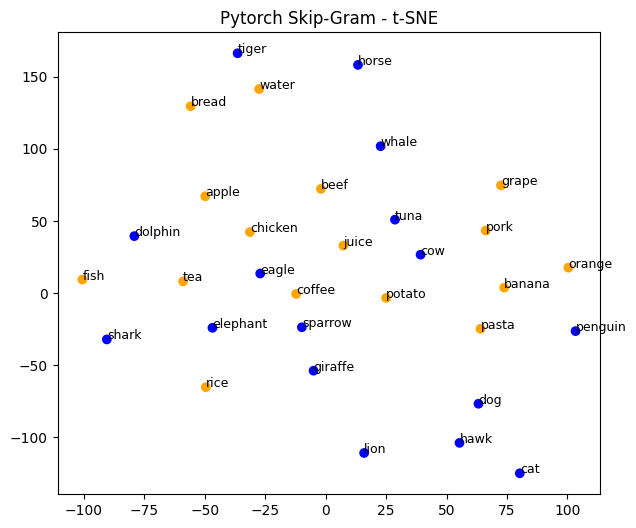

/Users/sv/Desktop/NU/STAT359/stat359/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sv/Desktop/NU/STAT359/stat359/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


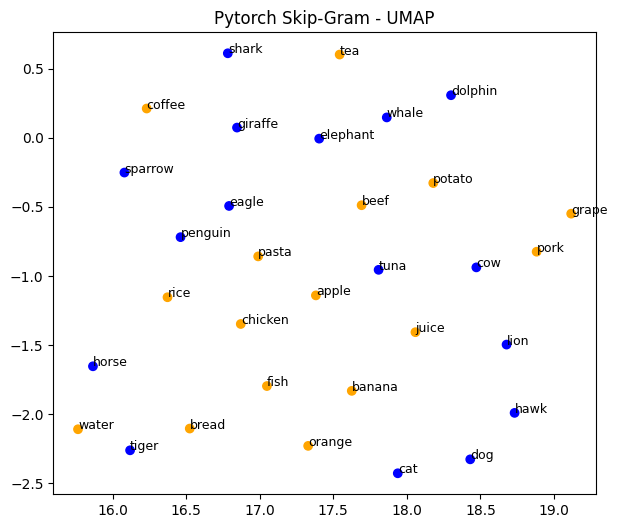

In [36]:
plot_tsne_umap("Pytorch Skip-Gram", embeddings, word2idx, all_words, labels)

#### Gensim Word2Vec trained on Text8 100d

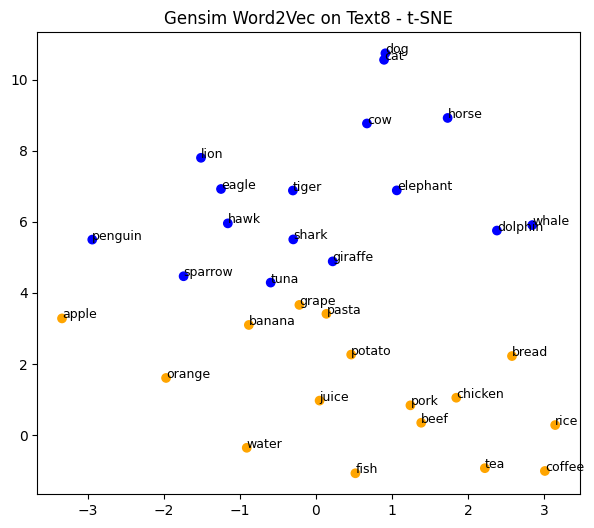

/Users/sv/Desktop/NU/STAT359/stat359/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sv/Desktop/NU/STAT359/stat359/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


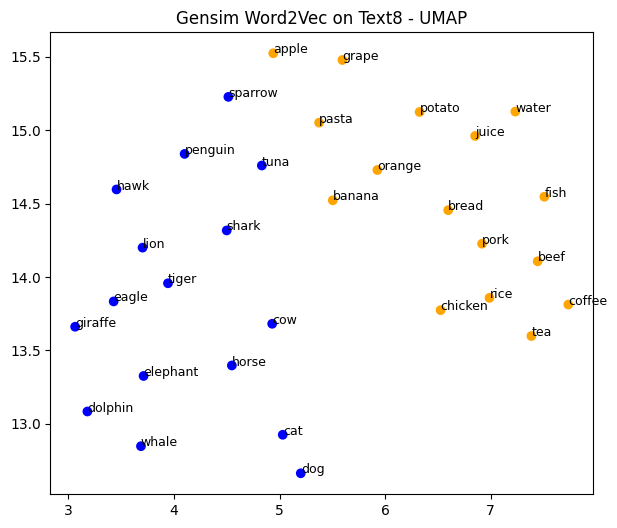

In [37]:
plot_tsne_umap("Gensim Word2Vec on Text8", embeddings_gensim, word2idx_gensim, all_words, labels)

#### Gensim Word2Vec Google News (300d)

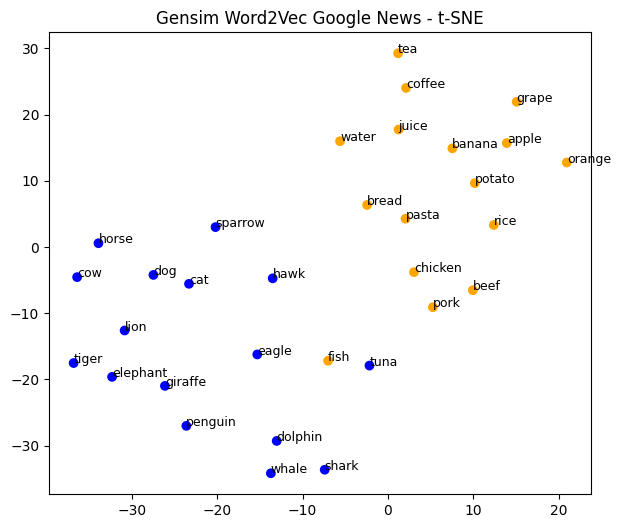

/Users/sv/Desktop/NU/STAT359/stat359/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sv/Desktop/NU/STAT359/stat359/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


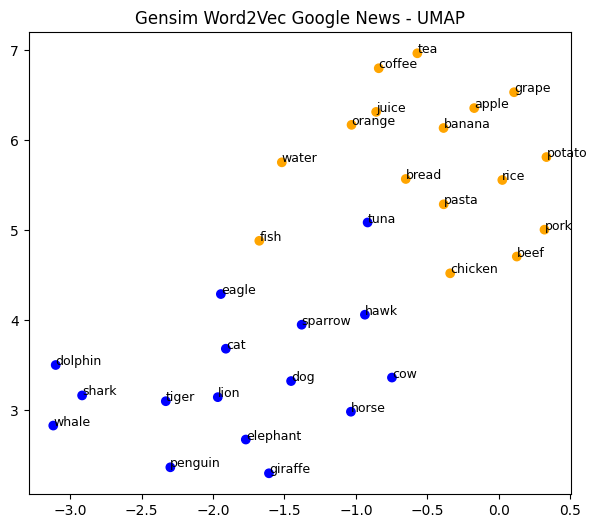

In [38]:
plot_tsne_umap("Gensim Word2Vec Google News", embeddings_google, word2idx_google, all_words, labels)

#### Gensim FastText Wiki News Subwords (300d)

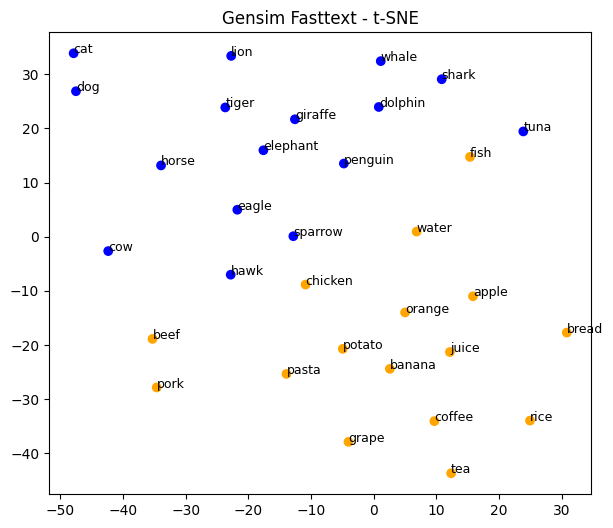

/Users/sv/Desktop/NU/STAT359/stat359/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sv/Desktop/NU/STAT359/stat359/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


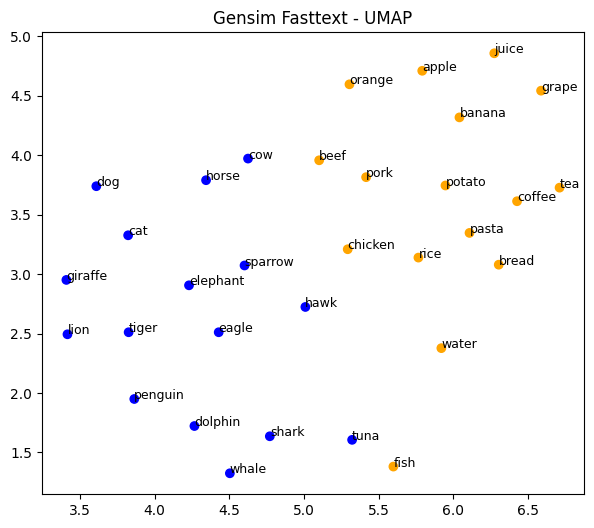

In [39]:
plot_tsne_umap("Gensim Fasttext", embeddings_fasttext, word2idx_fasttext, all_words, labels)

Across all embedding sources, words belonging to the same semantic category (animals and foods) tend to cluster together and the seperation is overall quiet consistent across embedding. The pretrained embeddings (Google News Word2Vec and FastText) show clearer separation between categories, reflecting training on much larger corpora. FastText produces the most compact clusters probabily due to its use of subword information, while the Pytorch skip_gram embeddings show more overlap between categories.

## Short Answer Questions

1. Which embeddings performed best at capturing sentence meaning?
Overall, pretrained FastText embeddings perform the best at capturing sentence-level semantics. In the sentence similarity task, FastText consistently ranks higher scores to semantically related sentences while maintaining clearer separation from unrelated sentences. In the visualization, FastText also showed strong clustering within semantic categories.
2. Were the pretrained embeddings significantly better than your own? Why or why not?
Yes, the pretrained embeddings (Google News Word2vec and FastText) were clearly better than my own model trained on Text8. The pretrained models were trained on massive, diverse corpora, which allowed them to capture richer semantic relationships. In contrast, my own model was trained on a smaller, more limited dataset, leading to less robust embeddings. The higher dimensionality (300d vs 100d) of the pretrained embeddings also contributed to their performance.
3. What factors might explain the differences in performance?
First is training data size and diversity. Pretrained models use billions of tokens, while our own model uses limited data. Second is embedding dimension, higher dimensional embeddings(300d) can capture more semantic differents than lower dimensions. Third is training objective quality. Industrial-scale pretrained models are optimized with extensive tuning and longer training times, leading to better quality.

## Bonus exploration - Word Analogies

In [10]:
def analogy(a, b, c, embeddings, word2idx, topk=10):
    """
    Solve analogy: a - b + c ≈ ?
    """

    vec = (
        embeddings[word2idx[a]]
        - embeddings[word2idx[b]]
        + embeddings[word2idx[c]]
    )

    sims = []
    for w, idx in word2idx.items():
        if w in {a, b, c}:
            continue
        sim = cosine_sim(vec, embeddings[idx])
        sims.append((w, sim))

    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[:topk]

#### Pytorch Skip-Gram Embeddings

In [11]:
print("=== Word Analogy: king - man + woman ===")
results = analogy("king", "man", "woman", embeddings, word2idx)

for w, s in results:
    print(f"{w:10s} | {s:.4f}")

=== Word Analogy: king - man + woman ===
admirer    | 0.5230
tributes   | 0.5196
million    | 0.4969
greco      | 0.4967
abacus     | 0.4948
opus       | 0.4931
tour       | 0.4924
giovanni   | 0.4912
wired      | 0.4879
factor     | 0.4878


#### Gensim Word2Vec trained on Text8 100d

In [16]:
print("=== Word Analogy: king - man + woman ===")
results_gensim = analogy("king", "man", "woman", embeddings_gensim, word2idx_gensim)
for w, s in results_gensim:
    print(f"{w:10s} | {s:.4f}")


=== Word Analogy: king - man + woman ===
queen      | 0.6774
throne     | 0.6570
empress    | 0.6329
prince     | 0.6318
isabella   | 0.6279
emperor    | 0.6260
daughter   | 0.6222
regent     | 0.6219
princess   | 0.6218
elizabeth  | 0.6164


#### Gensim Word2Vec Google News (300d)

In [17]:
print("=== Word Analogy: king - man + woman ===")
results_google = analogy("king", "man", "woman", embeddings_google, word2idx_google)
for w, s in results_google:
    print(f"{w:10s} | {s:.4f}")

=== Word Analogy: king - man + woman ===
queen      | 0.7301
monarch    | 0.6455
princess   | 0.6156
crown_prince | 0.5819
prince     | 0.5777
kings      | 0.5614
sultan     | 0.5377
Queen_Consort | 0.5344
queens     | 0.5290
ruler      | 0.5247


#### Gensim FastText Wiki News Subwords (300d)

In [18]:
print("=== Word Analogy: king - man + woman ===")
results_fasttext = analogy("king", "man", "woman", embeddings_fasttext, word2idx_fasttext)
for w, s in results_fasttext:
    print(f"{w:10s} | {s:.4f}")

=== Word Analogy: king - man + woman ===
queen      | 0.7570
queen-mother | 0.6897
king-      | 0.6787
queen-consort | 0.6555
monarch    | 0.6456
kings      | 0.6409
child-king | 0.6347
king-elect | 0.6344
boy-king   | 0.6307
ex-queen   | 0.6193


Obvously, the pretrained embeddings especially(Google News Word2Vec and FastText) successfully place the expected target word "queen" among the top results for the analogy task "king - man + woman" and got a high cos-sim score, indicating that gender and role relationships are well captured. While the custom-trained embeddings (Pytorch Skip-Gram) model performs less consistently due to limited training data and lower dimensionality, which reduces its ability to learn abstract semantic relatioships. Overall, the pretrained models demonstrate a stronger understanding of word analogies, reflecting their extensive training on large, diverse corpora.

## AI Use Disclosure (Required)

If you used any AI-enabled tools (e.g., ChatGPT, GitHub Copilot, Claude, or other LLM assistants) while working on this assignment, you must disclose that use here. The goal is transparency-not punishment.

In your disclosure, briefly include:
- **Tool(s) used:** (name + version if known)
- **How you used them:** (e.g., concept explanation, debugging, drafting code, rewriting text)
- **What you verified yourself:** (e.g., reran the notebook, checked outputs/plots, checked shapes, read documentation)
- **What you did *not* use AI for (if applicable):** (optional)

You are responsible for the correctness of your submission, even if AI suggested code or explanations.

- **Tool(s) used:** CHatGPT-5.2
- **How you used them:** (e.g., concept explanation, debugging, drafting code, rewriting text) Drafting implementation code of the Word2Vec model embedding and the code structure for analysis part. Helped in debugging some errors in the code. Explaining concepts related to word embeddings and similarity measures.
- **What you verified yourself:** reran the notebook, checked outputs/plots, and compare different embedding results.